# Assignment 04: Object Detection, Semantic Segmentation, and Face Recognition
**Студент:** [впиши имя]  
**Группа:** [впиши группу]

# Часть 1: Transpose Convolution (ручной расчёт)

Дано:

**Input**
\[
\begin{bmatrix}
2 & 1 \\
3 & 2
\end{bmatrix}
\]

**Filter 3×3**
\[
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
\]

**Stride = 2, Padding = 1**

### 1. Размер выхода
Формула:
\[
\text{Output size} = (\text{Input size} - 1)\times \text{Stride} + \text{Filter size} - 2\times \text{Padding}
\]

\[
(2 - 1)\times 2 + 3 - 2\times 1 = 3
\]

Значит итоговый выход будет **3×3**.

### 2. Вклад каждого элемента входа
Каждый элемент входа “кладёт” свой фильтр в выходную матрицу с шагом stride=2.

- Для `2` в позиции (0,0):
\[
\begin{bmatrix}
2 & 2 & 2 \\
2 & 2 & 2 \\
2 & 2 & 2
\end{bmatrix}
\]

- Для `1` в позиции (0,1) со сдвигом вправо на 2:
\[
\begin{bmatrix}
0 & 1 & 1 \\
0 & 1 & 1 \\
0 & 1 & 1
\end{bmatrix}
\]

- Для `3` в позиции (1,0) со сдвигом вниз на 2:
\[
\begin{bmatrix}
0 & 0 & 0 \\
3 & 3 & 3 \\
3 & 3 & 3
\end{bmatrix}
\]

- Для `2` в позиции (1,1) со сдвигом вниз и вправо:
\[
\begin{bmatrix}
0 & 0 & 0 \\
0 & 2 & 2 \\
0 & 2 & 2
\end{bmatrix}
\]

### 3. Складываем перекрытия
Получаем итог:
\[
\begin{bmatrix}
2 & 3 & 1 \\
5 & 8 & 3 \\
3 & 5 & 2
\end{bmatrix}
\]

### Ответ
Итоговая матрица transpose convolution:
\[
\boxed{
\begin{bmatrix}
2 & 3 & 1 \\
5 & 8 & 3 \\
3 & 5 & 2
\end{bmatrix}
}
\]

In [18]:
# Проверка результата через PyTorch
import torch

x = torch.tensor([[[[2.0, 1.0],
                    [3.0, 2.0]]]])

w = torch.ones((1, 1, 3, 3))

y = torch.nn.functional.conv_transpose2d(x, w, stride=2, padding=1)
print(y[0, 0])

tensor([[2., 3., 1.],
        [5., 8., 3.],
        [3., 5., 2.]])


# Часть 2: Обнаружение объектов с помощью YOLO

# 2.1 Базовое обнаружение объектов

In [19]:
# Установка и импорты
# Если библиотека уже установлена, строку ниже можно закомментировать
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request

In [20]:
# Загружаем предобученную модель YOLOv8
model = YOLO('yolov8n.pt')  # nano-модель

In [21]:
from ultralytics.utils import ASSETS
from pathlib import Path

image_paths = [
    str(Path(ASSETS) / "bus.jpg"),
    str(Path(ASSETS) / "zidane.jpg"),
    str(Path(ASSETS) / "bus.jpg")
]

print("Images:", image_paths)

Images: ['/usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg', '/usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg', '/usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg']


Image: /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg

image 1/1 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 216.6ms
Speed: 4.3ms preprocess, 216.6ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 480)


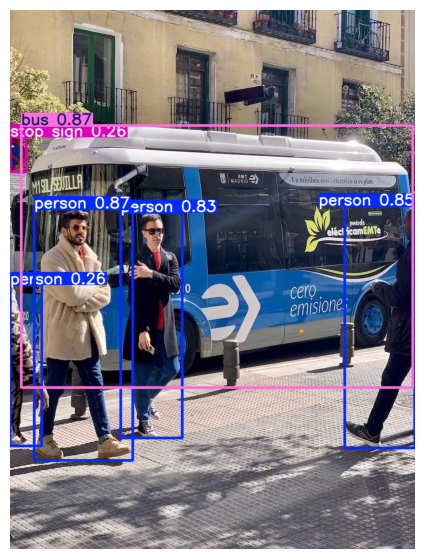

Класс: bus
Confidence: 0.8734
xywh (absolute): [413.94, 494.06, 782.13, 525.56]
xywh (normalized): [0.511, 0.4575, 0.9656, 0.4866]
------------------------------
Класс: person
Confidence: 0.8657
xywh (absolute): [146.95, 650.63, 196.8, 504.15]
xywh (normalized): [0.1814, 0.6024, 0.243, 0.4668]
------------------------------
Класс: person
Confidence: 0.8528
xywh (absolute): [739.6, 634.61, 140.25, 484.85]
xywh (normalized): [0.9131, 0.5876, 0.1731, 0.4489]
------------------------------
Класс: person
Confidence: 0.8252
xywh (absolute): [283.24, 631.67, 123.45, 451.74]
xywh (normalized): [0.3497, 0.5849, 0.1524, 0.4183]
------------------------------
Класс: person
Confidence: 0.2611
xywh (absolute): [31.5, 711.98, 63.01, 322.92]
xywh (normalized): [0.0389, 0.6592, 0.0778, 0.299]
------------------------------
Класс: stop sign
Confidence: 0.2551
xywh (absolute): [16.31, 289.67, 32.5, 70.41]
xywh (normalized): [0.0201, 0.2682, 0.0401, 0.0652]
------------------------------
Image: /usr/loca

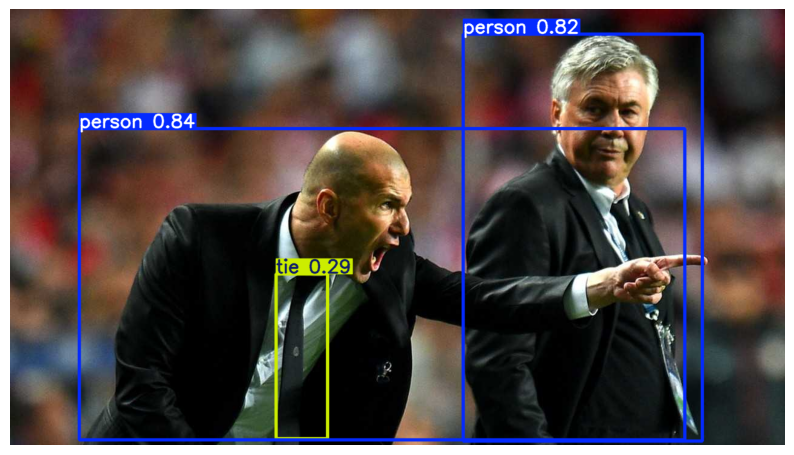

Класс: person
Confidence: 0.8360
xywh (absolute): [614.67, 454.65, 999.6, 514.48]
xywh (normalized): [0.4802, 0.6315, 0.7809, 0.7146]
------------------------------
Класс: person
Confidence: 0.8190
xywh (absolute): [945.77, 377.44, 394.61, 671.17]
xywh (normalized): [0.7389, 0.5242, 0.3083, 0.9322]
------------------------------
Класс: tie
Confidence: 0.2910
xywh (absolute): [481.91, 573.12, 84.87, 272.09]
xywh (normalized): [0.3765, 0.796, 0.0663, 0.3779]
------------------------------
Image: /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg

image 1/1 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 224.4ms
Speed: 4.6ms preprocess, 224.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)


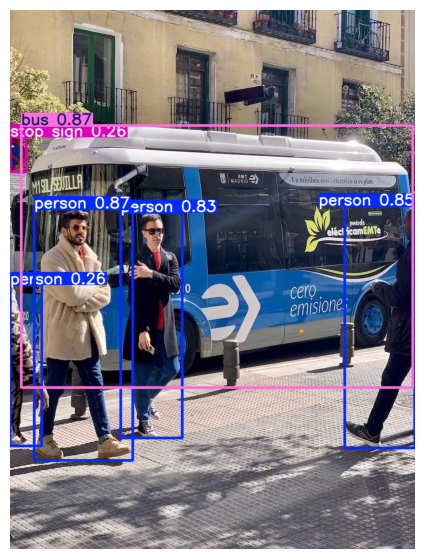

Класс: bus
Confidence: 0.8734
xywh (absolute): [413.94, 494.06, 782.13, 525.56]
xywh (normalized): [0.511, 0.4575, 0.9656, 0.4866]
------------------------------
Класс: person
Confidence: 0.8657
xywh (absolute): [146.95, 650.63, 196.8, 504.15]
xywh (normalized): [0.1814, 0.6024, 0.243, 0.4668]
------------------------------
Класс: person
Confidence: 0.8528
xywh (absolute): [739.6, 634.61, 140.25, 484.85]
xywh (normalized): [0.9131, 0.5876, 0.1731, 0.4489]
------------------------------
Класс: person
Confidence: 0.8252
xywh (absolute): [283.24, 631.67, 123.45, 451.74]
xywh (normalized): [0.3497, 0.5849, 0.1524, 0.4183]
------------------------------
Класс: person
Confidence: 0.2611
xywh (absolute): [31.5, 711.98, 63.01, 322.92]
xywh (normalized): [0.0389, 0.6592, 0.0778, 0.299]
------------------------------
Класс: stop sign
Confidence: 0.2551
xywh (absolute): [16.31, 289.67, 32.5, 70.41]
xywh (normalized): [0.0201, 0.2682, 0.0401, 0.0652]
------------------------------


In [22]:
# Запуск обнаружения объектов на 3 изображениях
for img_path in image_paths:
    print("=" * 70)
    print("Image:", img_path)

    results = model(img_path)
    result = results[0]

    # Картинка с рамками
    plotted = result.plot()
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # Информация о детекциях
    for det in result.boxes:
        cls_id = int(det.cls[0].item())
        cls_name = model.names[cls_id]
        conf = float(det.conf[0].item())
        xywh = det.xywh[0].tolist()
        xywhn = det.xywhn[0].tolist()

        print(f"Класс: {cls_name}")
        print(f"Confidence: {conf:.4f}")
        print(f"xywh (absolute): {[round(v, 2) for v in xywh]}")
        print(f"xywh (normalized): {[round(v, 4) for v in xywhn]}")
        print("-" * 30)

# 2.2 Понимание вывода YOLO

### Что означает confidence score?
Confidence score показывает, насколько модель уверена, что найденный объект действительно существует и что рамка хорошо его покрывает. Значение находится в диапазоне от 0 до 1. Чем выше score, тем надёжнее детекция.

### Как нормализуются координаты bounding box?
Нормализованные координаты считаются относительно размера изображения:
\[
x_{norm} = \frac{x}{W}, \quad y_{norm} = \frac{y}{H}, \quad
w_{norm} = \frac{w}{W}, \quad h_{norm} = \frac{h}{H}
\]
Поэтому все значения находятся в диапазоне **0–1**.

### Разница между `xyxy` и `xywh`
- **xyxy** = `(x_min, y_min, x_max, y_max)`  
  Это координаты двух углов прямоугольника.
- **xywh** = `(x_center, y_center, width, height)`  
  Это центр рамки и её размеры.

`xyxy` удобно использовать для рисования прямоугольника, а `xywh` — для хранения и обучения модели.

# 2.3 Non-Max Suppression (NMS)

In [23]:
# Проверка разных conf thresholds
image_path = image_paths[0]
conf_thresholds = [0.25, 0.5, 0.75]

print("Разные confidence thresholds")
for conf in conf_thresholds:
    results = model(image_path, conf=conf, iou=0.5, verbose=False)
    print(f"conf = {conf}, найдено объектов = {len(results[0].boxes)}")

Разные confidence thresholds
conf = 0.25, найдено объектов = 6
conf = 0.5, найдено объектов = 4
conf = 0.75, найдено объектов = 4


In [24]:
# Проверка разных iou thresholds
iou_thresholds = [0.3, 0.5, 0.7]

print("Разные IoU thresholds")
for iou in iou_thresholds:
    results = model(image_path, conf=0.5, iou=iou, verbose=False)
    print(f"iou = {iou}, найдено объектов = {len(results[0].boxes)}")

Разные IoU thresholds
iou = 0.3, найдено объектов = 4
iou = 0.5, найдено объектов = 4
iou = 0.7, найдено объектов = 4


### Объяснение результатов NMS

- Если **увеличить `conf`**, модель станет более строгой и будет отбрасывать слабые предсказания. Обычно найденных объектов становится меньше.
- Если **уменьшить `conf`**, появится больше боксов, но среди них может быть больше ложных.
- Если **уменьшить `iou`** в NMS, перекрывающиеся боксы будут удаляться агрессивнее.
- Если **увеличить `iou`**, модель позволит сохранить больше похожих боксов, поэтому иногда остаются почти одинаковые рамки.

# 2.4 Обнаружение объектов на видео (Bonus)

In [25]:
# Пример для видео
# Положите своё видео в ту же папку и укажите путь
# video_path = "video.mp4"
# results = model(video_path, save=True)
# print("Готово. Результат сохранён в папку runs/detect/predict")

# Часть 3: Распознавание лиц с помощью DeepFace

# 3.1 Проверка лиц (Verification)

In [26]:
# Установка и импорты
!pip install deepface -q

from deepface import DeepFace
import os
import numpy as np
import urllib.request

In [27]:
# Скачаем примеры лиц
import os
import cv2
import numpy as np
import urllib.request

face_dir = "face_images"
os.makedirs(face_dir, exist_ok=True)

def download_file(url, path):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as response, open(path, "wb") as f:
        f.write(response.read())

# 2 фото одного человека
url_a1 = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg"
url_a2 = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama2.jpg"

# 1 фото второго человека
url_b1 = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/biden.jpg"

path_a1 = os.path.join(face_dir, "person_a_1.jpg")
path_a2 = os.path.join(face_dir, "person_a_2.jpg")
path_b1 = os.path.join(face_dir, "person_b_1.jpg")
path_b2 = os.path.join(face_dir, "person_b_2.jpg")

if not os.path.exists(path_a1):
    download_file(url_a1, path_a1)

if not os.path.exists(path_a2):
    download_file(url_a2, path_a2)

if not os.path.exists(path_b1):
    download_file(url_b1, path_b1)

# второе фото person B делаем из первого автоматически,
# чтобы остальной код не менять
if not os.path.exists(path_b2):
    img = cv2.imread(path_b1)
    img2 = cv2.convertScaleAbs(img, alpha=1.0, beta=20)  # чуть светлее
    cv2.imwrite(path_b2, img2)

face_paths = {
    "person_a_1": path_a1,
    "person_a_2": path_a2,
    "person_b_1": path_b1,
    "person_b_2": path_b2,
}

print(face_paths)

{'person_a_1': 'face_images/person_a_1.jpg', 'person_a_2': 'face_images/person_a_2.jpg', 'person_b_1': 'face_images/person_b_1.jpg', 'person_b_2': 'face_images/person_b_2.jpg'}


In [28]:
# Same-person pairs
same_pairs = [
    ("person_a_1", "person_a_2"),
]

print("Testing SAME-PERSON verification")
for a, b in same_pairs:
    result = DeepFace.verify(
        img1_path=face_paths[a],
        img2_path=face_paths[b],
        enforce_detection=False
    )
    print(f"Pair: {a} vs {b}")
    print(f"Verified: {result['verified']}")
    print(f"Distance: {result['distance']:.4f}")
    print(f"Threshold: {result['threshold']:.4f}")
    print("-" * 40)

Testing SAME-PERSON verification
Pair: person_a_1 vs person_a_2
Verified: True
Distance: 0.6537
Threshold: 0.6800
----------------------------------------


In [29]:
# Different-person pairs
diff_pairs = [
    ("person_a_1", "person_b_1"),
    ("person_a_2", "person_b_2"),
]

print("Testing DIFFERENT-PERSON verification")
for a, b in diff_pairs:
    result = DeepFace.verify(
        img1_path=face_paths[a],
        img2_path=face_paths[b],
        enforce_detection=False
    )
    print(f"Pair: {a} vs {b}")
    print(f"Verified: {result['verified']}")
    print(f"Distance: {result['distance']:.4f}")
    print(f"Threshold: {result['threshold']:.4f}")
    print("-" * 40)

Testing DIFFERENT-PERSON verification
Pair: person_a_1 vs person_b_1
Verified: False
Distance: 0.8454
Threshold: 0.6800
----------------------------------------
Pair: person_a_2 vs person_b_2
Verified: False
Distance: 0.8146
Threshold: 0.6800
----------------------------------------


**Отчёт о результатах:**

- Для фотографий **одного и того же человека** расстояние между эмбеддингами обычно меньше.
- Для фотографий **разных людей** расстояние обычно больше.
- Если distance < threshold, модель считает, что это один и тот же человек.
- Если distance > threshold, модель считает, что это разные люди.

**Что значит distance metric?**  
Это численное расстояние между векторными представлениями лиц. Маленькое расстояние означает, что лица похожи, большое — что отличаются.

# 3.2 Анализ лиц (Age / Gender / Emotion)

In [30]:
print("Face Analysis - Age, Gender, Emotion")

for name, path in face_paths.items():
    analysis = DeepFace.analyze(
        img_path=path,
        actions=['age', 'gender', 'emotion'],
        enforce_detection=False
    )

    if isinstance(analysis, list):
        analysis = analysis[0]

    print(f"Image: {name}")
    print(f"Age: {analysis['age']}")
    print(f"Dominant gender: {analysis['dominant_gender']}")
    print(f"Dominant emotion: {analysis['dominant_emotion']}")
    print("-" * 40)

Face Analysis - Age, Gender, Emotion


Action: age:   0%|          | 0/3 [00:00<?, ?it/s]    

26-03-19 03:53:04 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 11.0M/539M [00:00<00:09, 54.3MB/s]
  4%|▍         | 21.5M/539M [00:00<00:07, 65.1MB/s]
  6%|▌         | 32.0M/539M [00:00<00:07, 66.2MB/s]
  8%|▊         | 42.5M/539M [00:00<00:06, 75.0MB/s]
  9%|▉         | 50.3M/539M [00:00<00:07, 66.5MB/s]
 11%|█         | 57.7M/539M [00:00<00:09, 53.3MB/s]
 12%|█▏        | 63.4M/539M [00:01<00:09, 51.6MB/s]
 14%|█▎        | 73.9M/539M [00:01<00:07, 61.5MB/s]
 15%|█▌        | 82.3M/539M [00:01<00:06, 66.7MB/s]
 17%|█▋        | 89.7M/539M [00:01<00:09, 47.7MB/s]
 18%|█▊        | 95.4M/539M [00:01<00:10, 43.5MB/s]
 20%|█▉        | 105M/539M [00:01<00:08, 51.1MB/s] 
 22%|██▏       | 116M/539M [00:02<00:07, 55.9MB/s]
 23%|██▎       | 126M/539M [00:02<00:06, 60.3MB/s]
 25%|██▌       | 137M/539M [00:02<00:06, 65.0MB/s]
 27%|██▋       | 147M

26-03-19 03:53:20 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


...

Image: person_a_2
Age: 45
Dominant gender: Man
Dominant emotion: angry
----------------------------------------


Action: emotion: 100%|██████████| 3/3 [00:01<00:00,  2.23it/s]


Image: person_b_1
Age: 48
Dominant gender: Man
Dominant emotion: sad
----------------------------------------


Action: emotion: 100%|██████████| 3/3 [00:01<00:00,  2.29it/s]

Image: person_b_2
Age: 48
Dominant gender: Man
Dominant emotion: sad
----------------------------------------


### Обсуждение точности
- **Возраст** часто определяется приблизительно и может ошибаться на несколько лет.
- **Пол** обычно определяется точнее, чем возраст.
- **Эмоция** — самая нестабильная часть, потому что выражение лица зависит от угла, освещения и качества фото.

Итог: DeepFace может давать полезные предсказания, но они не всегда идеально совпадают с реальностью.

# 3.3 Векторы признаков (Embeddings)

In [31]:
# Получение эмбеддингов
embeddings = {}

for name, path in face_paths.items():
    rep = DeepFace.represent(
        img_path=path,
        model_name="Facenet",
        enforce_detection=False
    )
    if isinstance(rep, list):
        embeddings[name] = np.array(rep[0]["embedding"])
    else:
        embeddings[name] = np.array(rep["embedding"])

    print(name, "embedding dimension =", len(embeddings[name]))

26-03-19 03:53:46 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:01<00:00, 56.0MB/s]


person_a_1 embedding dimension = 128
person_a_2 embedding dimension = 128
person_b_1 embedding dimension = 128
person_b_2 embedding dimension = 128


In [32]:
# Евклидово расстояние между эмбеддингами
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

same_dist = euclidean_distance(embeddings["person_a_1"], embeddings["person_a_2"])
diff_dist1 = euclidean_distance(embeddings["person_a_1"], embeddings["person_b_1"])
diff_dist2 = euclidean_distance(embeddings["person_a_2"], embeddings["person_b_2"])

print("Same person distance:", round(float(same_dist), 4))
print("Different person distance 1:", round(float(diff_dist1), 4))
print("Different person distance 2:", round(float(diff_dist2), 4))

Same person distance: 7.4852
Different person distance 1: 16.4778
Different person distance 2: 16.859


### Почему расстояние меньше для одного человека?
Потому что модель старается размещать фотографии одного и того же человека близко друг к другу в пространстве признаков. Фото разных людей должны лежать дальше друг от друга.

# Часть 4: Понимание архитектуры U-Net

# 4.1 Архитектурная схема

Ниже приведена упрощённая схема U-Net с 3 encoder blocks и 3 decoder blocks.

![U-Net Diagram](unet_diagram.png)

Пояснение по размерам:
- Input: **256×256×3**
- После первого блока: **256×256×64**
- После pool: **128×128×64**
- После второго блока: **128×128×128**
- После pool: **64×64×128**
- После третьего блока: **64×64×256**
- Затем идёт decoder:
  - transpose conv → **128×128×128**
  - concat со skip connection
  - transpose conv → **256×256×64**
  - concat со skip connection
- Финальный слой даёт карту сегментации по пикселям.

# 4.2 Пропуск соединений (Skip Connections)

1. **Цель skip connections** — передавать пространственную информацию из encoder в decoder.

2. Во время downsampling сеть теряет часть точных деталей изображения. Skip connections помогают вернуть границы, формы и мелкие объекты.

3. Для объединения признаков из encoder и decoder используется **concatenation** по канальному измерению.

# 4.3 Реализация U-Net (упрощённая)

In [33]:
import torch
import torch.nn as nn

In [34]:
class DoubleConv(nn.Module):
    """Two consecutive Conv-BatchNorm-ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class DownBlock(nn.Module):
    """Downsampling block: MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        x = self.maxpool(x)
        x = self.conv(x)
        return x


class UpBlock(nn.Module):
    """Upsampling block: TransposeConv + Concatenate + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        # Если размеры отличаются на 1 пиксель, подгоняем
        if x.shape[2:] != skip.shape[2:]:
            x = nn.functional.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

In [35]:
# Проверка размеров
print("Testing U-Net components")

double_conv = DoubleConv(3, 64)
x = torch.randn(1, 3, 256, 256)
y = double_conv(x)
print("DoubleConv:", x.shape, "->", y.shape)

down = DownBlock(64, 128)
x2 = torch.randn(1, 64, 256, 256)
y2 = down(x2)
print("DownBlock:", x2.shape, "->", y2.shape)

up = UpBlock(256, 128)
x3 = torch.randn(1, 256, 64, 64)      # decoder input
skip = torch.randn(1, 128, 128, 128)  # skip connection
y3 = up(x3, skip)
print("UpBlock:", x3.shape, "and", skip.shape, "->", y3.shape)

Testing U-Net components
DoubleConv: torch.Size([1, 3, 256, 256]) -> torch.Size([1, 64, 256, 256])
DownBlock: torch.Size([1, 64, 256, 256]) -> torch.Size([1, 128, 128, 128])
UpBlock: torch.Size([1, 256, 64, 64]) and torch.Size([1, 128, 128, 128]) -> torch.Size([1, 128, 128, 128])


# Часть 5: Вопросы для понимания

## Обнаружение объектов

### 1. YOLO vs Sliding Window
Sliding window проверяет множество фрагментов изображения отдельно, поэтому работает медленно. YOLO делает предсказание для всего изображения за один проход через сеть, поэтому работает намного быстрее.

### 2. Anchor Boxes
Anchor boxes помогают модели находить объекты разных размеров и форм. Также они позволяют предсказывать несколько объектов в одной и той же области изображения.

### 3. IoU (Intersection over Union)
Формула:
\[
IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}
\]

Если `IoU ≥ 0.5`, это значит, что предсказанный бокс достаточно хорошо совпадает с правильным боксом и детекция считается корректной.

### 4. Bounding Box Regression
В YOLO координаты бокса кодируются относительно текущей grid cell:
- `bx`, `by` — положение центра бокса внутри клетки
- `bw`, `bh` — ширина и высота бокса, обычно относительно anchor box

## Семантическая сегментация

### 5. Classification vs Detection vs Segmentation
- **Classification**: один класс для всего изображения.
- **Object Detection**: класс + bounding box для каждого объекта.
- **Semantic Segmentation**: класс для каждого пикселя.

### 6. Зачем нужен transpose convolution?
Transpose convolution увеличивает пространственное разрешение карты признаков. В U-Net это нужно, чтобы восстановить размер изображения на пути decoder. Если использовать только обычные свёртки, разрешение будет только уменьшаться.

### 7. Per-pixel Classification
Если вход имеет размер `256×256`, а классов `10`, то выход обычно имеет форму:

`(256, 256, 10)`  или в формате PyTorch `([batch_size], 10, 256, 256)`

То есть для каждого пикселя предсказываются вероятности 10 классов.

## Распознавание лиц

### 8. Verification vs Recognition
- **Verification**: ответ на вопрос “это один и тот же человек или нет?”
- **Recognition**: определить, кто именно изображён на фото, среди многих людей.

Recognition сложнее, потому что модель должна выбирать из большого числа возможных людей, а не просто сравнивать две фотографии.

### 9. One-shot Learning
Face recognition считают задачей one-shot learning, потому что система должна узнавать человека даже по очень малому количеству примеров. Для этого модель учит не конкретные классы, а **функцию сходства** между лицами.

### 10. Triplet Loss
Три части:
- **Anchor** — базовое изображение
- **Positive** — фото того же человека
- **Negative** — фото другого человека

Margin `\(\alpha\)` нужен для того, чтобы модель не просто делала positive ближе negative, а делала это с запасом. Это улучшает разделение классов.

### 11. Siamese Networks
Siamese network использует две одинаковые сети с общими весами. Они преобразуют два изображения в эмбеддинги, а потом сравниваются эти векторы. Это удобно для face verification, потому что задача сводится к сравнению похожести двух лиц.

In [36]:
# Конец работы
print("Assignment 04 notebook is ready.")

Assignment 04 notebook is ready.
